**Visualisation**  
matplotlib can be used to visualise data for analysis (graph, histogram, scatter plots etc)  
Make installation with 'pip install pandas matplotlib numpy'

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [2]:
Index_Data = pd.read_csv ('Index.csv', parse_dates=['Date'], date_format="%d-%b-%y")
Index_Data.sort_values (by='Date', inplace=True)
print (Index_Data.dtypes)

Index Name               str
Date          datetime64[us]
Open                 float64
High                 float64
Low                  float64
Close                float64
dtype: object


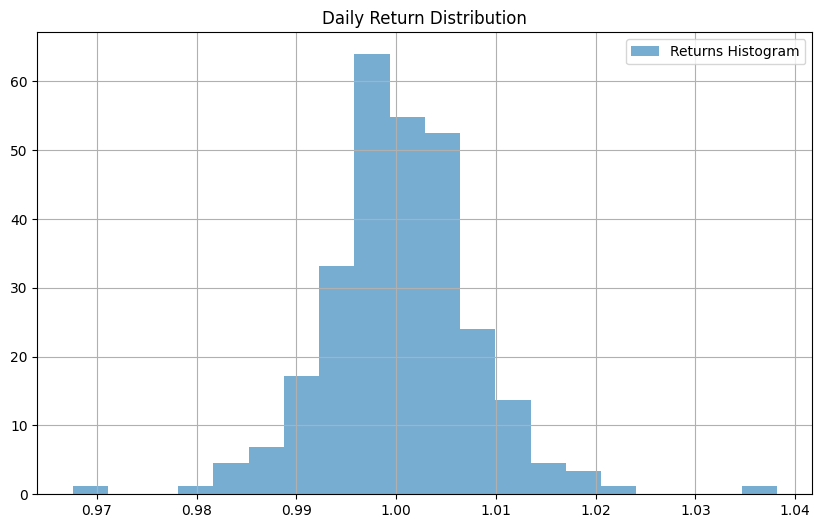

In [3]:
# Calculation of return value (Close to Close %)
Index_Data['Return'] = Index_Data['Close'] / Index_Data['Close'].shift(1)

# Visualization
plt.figure(figsize=(10, 6))
Index_Data['Return'].hist(bins=20, density=True, alpha=0.6, label='Returns Histogram')
plt.title('Daily Return Distribution')
plt.legend()
plt.show()

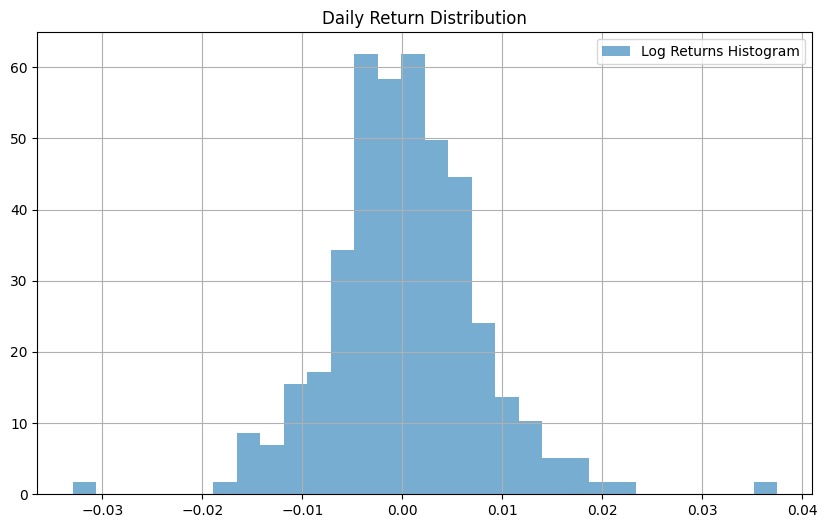

In [4]:
Index_Data['Log_Return'] = np.log(Index_Data['Close'] / Index_Data['Close'].shift(1))
plt.figure(figsize=(10, 6))
Index_Data['Log_Return'].hist(bins=30, density=True, alpha=0.6, label='Log Returns Histogram')
plt.title('Daily Return Distribution')
plt.legend()
plt.show()

In [ ]:
# Calculation of lagged return
Index_Data['Lagged_Return'] = Index_Data['Log_Return'].shift(1)

# Visualization
plt.figure(figsize=(6, 6))
plt.scatter(Index_Data['Lagged_Return'], Index_Data['Log_Return'], alpha=0.5, s=5)
plt.title('Current Return vs. Lagged Return')
plt.xlabel('Return (t-1)')
plt.ylabel('Return (t)')
plt.axhline(0, color='red', linestyle='--', linewidth=0.5)
plt.axvline(0, color='red', linestyle='--', linewidth=0.5)
plt.show()

In [ ]:
# get the return values, date and month
Index_Data['return'] = Index_Data['Close'].pct_change()
Index_Data['month'] = Index_Data['Date'].dt.month
Index_Data['day'] = Index_Data['Date'].dt.day

# Create a pivot table with date X month for returns
pivot = Index_Data.pivot_table(index='day', columns='month', values='return')

# Create a heat map
plt.figure(figsize=(8, 6))
plt.imshow(pivot, aspect='auto', interpolation='nearest')
plt.colorbar(label='Daily Return')
plt.title('Daily Returns Heatmap (day vs month)')
plt.xlabel('Month')
plt.ylabel('Day')
plt.tight_layout()
plt.show()


In [ ]:
cum_max = Index_Data['Close'].cummax()
drawdown = (Index_Data['Close'] - cum_max) / cum_max

plt.figure(figsize=(10, 4))
plt.plot(Index_Data['Date'], drawdown, label='Drawdown')
plt.fill_between(Index_Data['Date'], drawdown, 0, where=(drawdown < 0), alpha=0.3)

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.title('Drawdown')
plt.tight_layout()
plt.show()

